In [1]:
############################################################
# Headers

import os
import re
import sys
import cProfile
import configparser
import copy
from background import *

from FDM import *
from init import *
sys.path.insert( 0, "../base" )
from data_field import *
from grid import *
from profile_base import *
from source import *
from unit import *
from utils import *
import numpy      as  np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
plt.rcParams[ 'image.cmap' ] = 'turbo'
import numpy as np
np.set_printoptions(edgeitems=3)
np.core.arrayprint._line_width = 30
from binary_io  import binary_io



In [2]:
config_setup( "H24.par" )

In [3]:
def spiral_h24( R, phi ): #Polar modification to disc to be stored separately
    def f( m, gam, R, phi ):
        Ra = 9640 * units.pc / units.l0
        i = 12.5 * np.pi / 180
        return np.cos( m * ( phi + gam ) - ( m / np.tan( i ) ) * np.log( R / Ra ) )
    S = 0
    sigmasp = 5e3 * units.pc / units.l0
    from scipy.special import iv
    for m, gam in zip( [ 2, 2 ], [ 139.5 * np.pi / 180, 
                                   69.75 * np.pi / 180 ] ):
        term1 = np.exp( ( -R**2 / sigmasp**2 ) * ( 1 - f( m, gam, R, phi ) ) )
        tern2 = np.exp( -R**2 / sigmasp**2 ) * iv( 0, R**2 / sigmasp**2 )
        S += term1 - tern2
    R0 = 8179 * units.pc / units.l0
    return 0.36 * R**2 / R0**2 * S

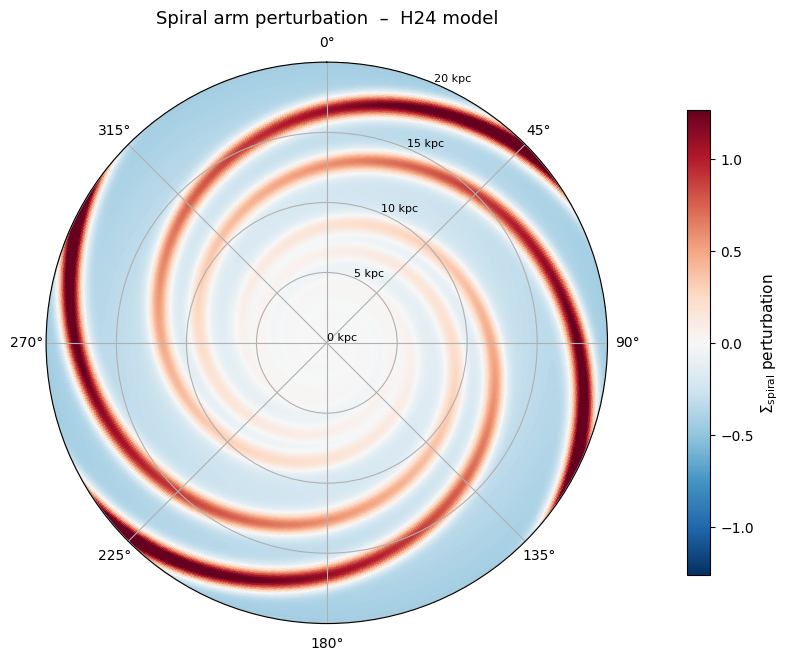

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.special import iv
# --- grid in polar coords ---
n_r, n_phi = 400, 600

R_min = 0.5  * units.pc / units.l0   # avoid log(0)  – set to ~0.5 pc
R_max = 2e4 * units.pc / units.l0   # 20 kpc outer edge

R_vals   = np.linspace(R_min, R_max, n_r)
phi_vals = np.linspace(0, 2 * np.pi, n_phi)

R_grid, phi_grid = np.meshgrid(R_vals, phi_vals)   # shape (n_phi, n_r)

Z = spiral_h24(R_grid, phi_grid)

# --- plot ---
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))

# diverging norm centred on 0 so positive/negative arms are distinct
vmax = np.percentile(np.abs(Z), 99)          # robust colour limit
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

mesh = ax.pcolormesh(
    phi_grid, R_grid, Z,
    cmap="RdBu_r",
    norm=norm,
    shading="auto",
)

# cosmetic tweaks
ax.set_theta_zero_location("N")   # 0° at top (Galactic North)
ax.set_theta_direction(-1)        # clockwise (conventional sky view)
ax.set_rlabel_position(22.5)

# convert R axis ticks back to kpc for readability
r_ticks_kpc = np.arange(0, 21, 5)           # 0 – 20 kpc
r_ticks_l0  = r_ticks_kpc * 1e3 * units.pc / units.l0
ax.set_rticks(r_ticks_l0)
ax.set_yticklabels([f"{r} kpc" for r in r_ticks_kpc], fontsize=8)

cbar = fig.colorbar(mesh, ax=ax, pad=0.12, fraction=0.035)
cbar.set_label(r"$\Sigma_\mathrm{spiral}$ perturbation", fontsize=11)

ax.set_title("Spiral arm perturbation  –  H24 model", va="bottom", fontsize=13)
plt.tight_layout()

In [8]:
result_flat, err_flat = dblquad(
    lambda R, phi: spiral_h24(R, phi),   # func(inner, outer)
    0, 2 * np.pi,                         # outer limits: phi in [0, 2π]
    lambda phi: R_min,                    # inner lower: R_min (constant)
    lambda phi: R_max,                    # inner upper: R_max (constant)
)
print(f"Flat integral:   {result_flat:.6e}  (err ≈ {err_flat:.1e})")

Flat integral:   -1.918181e-10  (err ≈ 1.8e-05)


In [6]:
53.1 * ( units.modot / units.m0 ) * ( units.pc / units.l0 )**-2

2149.278782939345

In [9]:
units.modot

1.9891e+33

In [3]:
bg = background(  )

In [ ]:
for j, i in bg.components.items( ):
    print( j, i )

bar_portail <background.background_source object at 0x762d2c566320>
disc_h24 <background.background_source object at 0x762d2c566ef0>
nsc_s20 <background.background_source object at 0x762d2c566260>
nsd_s20 <background.background_source object at 0x762d2c566440>


In [40]:
5416916990 / 40344751945

0.13426571558513023

In [4]:
# Background components can be adjusted
all_comp = { "bar_portail" : 1, "disc_s22" : 1, "nsc_s20" : 1, "nsd_s20" : 1 }
bg = background( all_components={} )

In [5]:

# Profile_flags can be adjusted
# Examples: disc, sech2, gauss, exp. zsolve is only applicable vertically
prof = profile( profile_flags=[ "disc", "sech2" ], 
                scale_lengths=[ [ 1500, 7000 ], [ 250 ] ],
                background=bg,
                config_flag='output_grid' )

Coords/mesh already in target coordinates


/mnt/scratch/cmz/kratos_galaxy/init/../base/data_field.py:296: RuntimeWarning: divide by zero encountered in divide
  def __truediv__( self, obj )  : return self._binary_op( obj, lambda a, b : a / b , False )
/mnt/scratch/cmz/kratos_galaxy/init/../base/data_field.py:296: RuntimeWarning: overflow encountered in divide
  def __truediv__( self, obj )  : return self._binary_op( obj, lambda a, b : a / b , False )
/mnt/scratch/cmz/kratos_galaxy/init/../base/data_field.py:295: RuntimeWarning: invalid value encountered in multiply
  def __mul__( self, obj )      : return self._binary_op( obj, lambda a, b : a * b , False )


In [11]:
prof.densprof

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.50524349e-10
  2.66486440e-08 2.36576829e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.51120248e-10
  1.76598637e-08 1.73470131e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 9.02764858e-11
  1.16066601e-08 1.26363973e-06]] [ [ 1 -3  0  0] ]

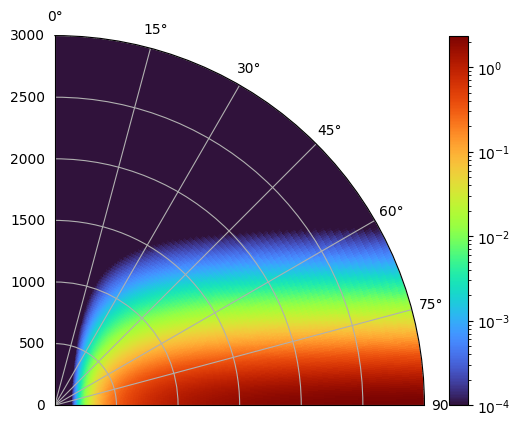

In [12]:
import matplotlib as mpl
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
s = ax.pcolormesh(prof.grid[ 1 ], prof.grid[ 0 ], prof.densprof, norm=mpl.colors.LogNorm(vmin=1e-4))
#s = ax.pcolormesh(prof.grid[ 1 ], prof.grid[ 0 ], prof.velprof )#, norm=mpl.colors.LogNorm(vmin=1e-4))
plt.ylim([0,3000])
plt.xlim([0,np.pi/2])
plt.colorbar(s)


In [8]:
fname = "../../init/galaxy_init.bin"
IC( prof, fname, use_background=False )

[512 256]


[]
[]
[]
[]


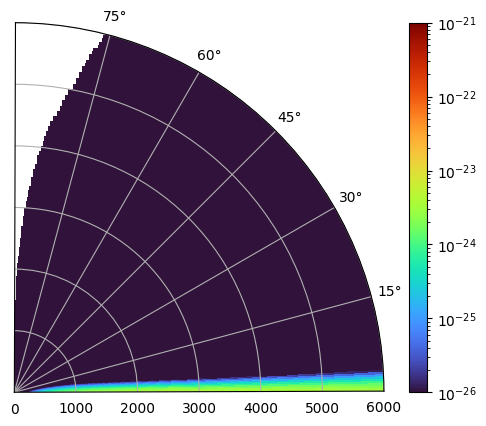

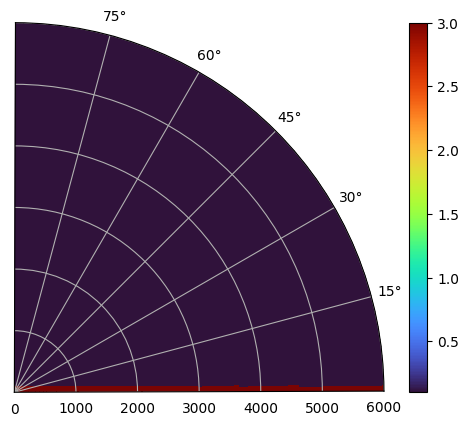

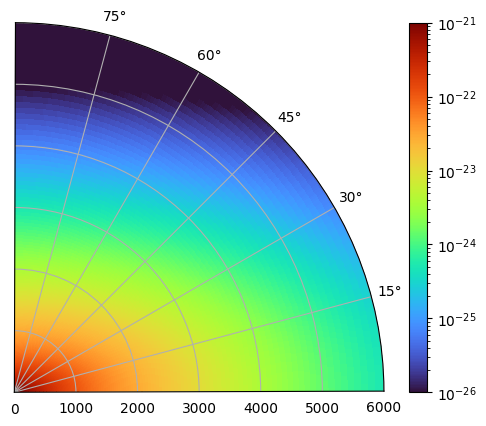

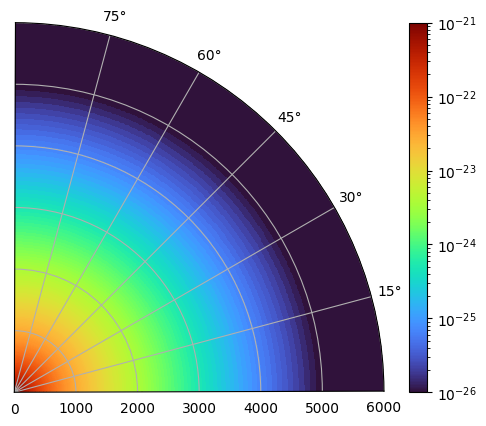

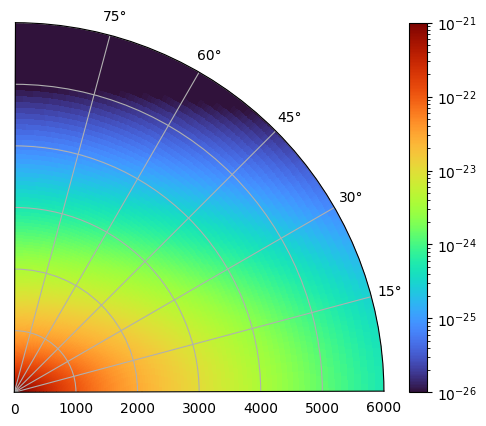

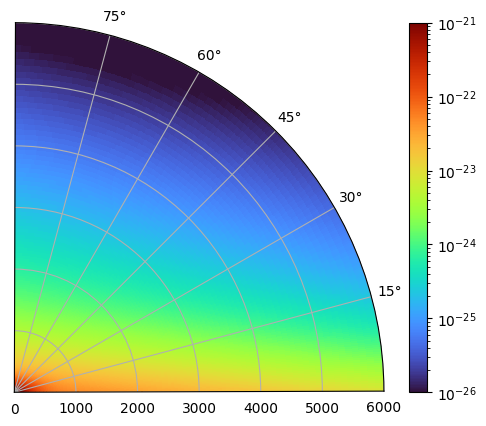

In [24]:
############################################################
# Check the data generating results
##############################
from matplotlib.pyplot import figure, pcolormesh
from numpy import pi

pc = units.pc

tst = binary_io( "../outputs/init_cond/cmz_init.bin" );
tst.open(  );
tst.read(  );

nfig = 0
########################################
# Hydro init cond

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );

aa = tst.as_array( 'hydro_rho' );
rr = tst.as_array( 'hydro_x_0'  );
tt = pi / 2 - tst.as_array( 'hydro_x_1'  );
# pi / 2 - theta for plots only! In Python's polar grid
# the polar angule is actually the latitutde

dd = aa.reshape( len( rr ), len( tt ) );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd, norm =
                     LogNorm( vmin = 1e-26, vmax= 1e-21 ) )
cbar = fig.colorbar( pcm )
ax.set_ylim( 0, 6000 )
print(dd[np.isnan(dd)])

########################################
# Hydro init cond met

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );

aa = tst.as_array( 'hydro_met' );
rr = tst.as_array( 'hydro_x_0'  );
tt = pi / 2 - tst.as_array( 'hydro_x_1'  );
# pi / 2 - theta for plots only! In Python's polar grid
# the polar angule is actually the latitutde

dd = aa.reshape( len( rr ), len( tt ) );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd )
cbar = fig.colorbar( pcm )
ax.set_ylim( 0, 6000 )
print(dd[np.isnan(dd)])
########################################
# Bar field

aa = tst.as_array( 'bar_data' );
rr = tst.as_array( 'bar_x_0'  );
tt = pi / 2 - tst.as_array( 'bar_x_1'  );
pp = tst.as_array( 'bar_x_2'  );
dd = aa.reshape( len( rr ), len( tt ), len( pp ) );

# Plot the r--theta slices
fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd[ :, :, 0 ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd[ :, :, -1 ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

# Plot the equatorial plance profile
fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( pp.min(  ), pp.max(  ) )
pcm = ax.pcolormesh( pp, rr / pc, dd[ :, -1, : ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

print(dd[np.isnan(dd)])
########################################
# BG DM field

aa = tst.as_array( 'bg_data' );
rr = tst.as_array( 'bg_x_0'  );
tt = pi / 2 - tst.as_array( 'bg_x_1'  );
dd = aa.reshape( len( rr ), len( tt ) );

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd, norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )

cbar = fig.colorbar( pcm )
##############################
# Close the binary_io object
print(dd[np.isnan(dd)])
tst.close(  );
#plt.savefig("test.png",dpi=300)
############################################################

In [18]:
aa = tst.as_array( 'hydro_vel' );
units.v0

97846.90512430239

[]
[]
[]
[]


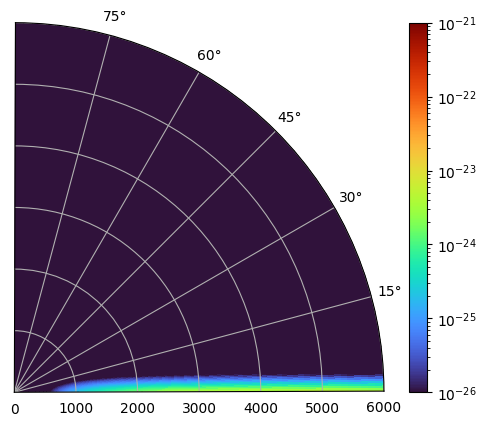

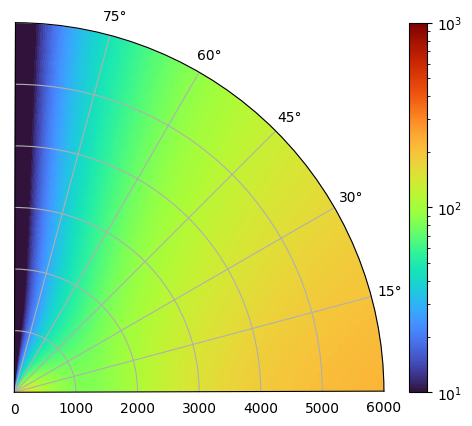

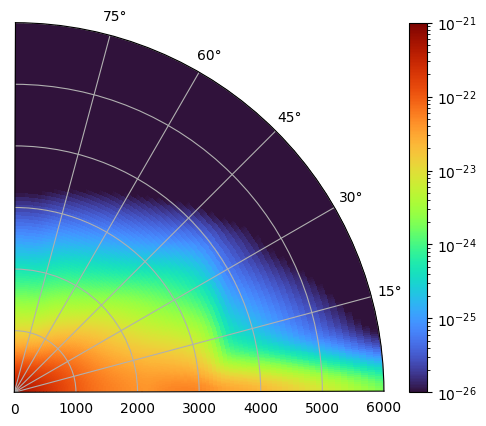

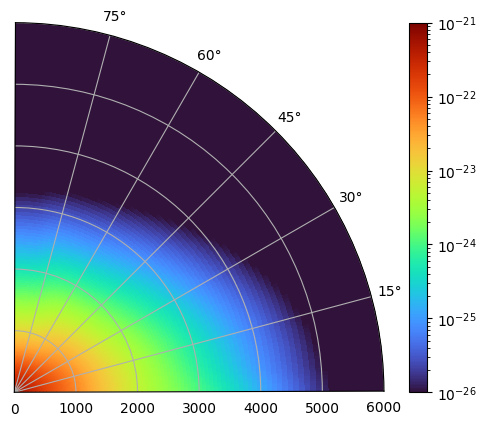

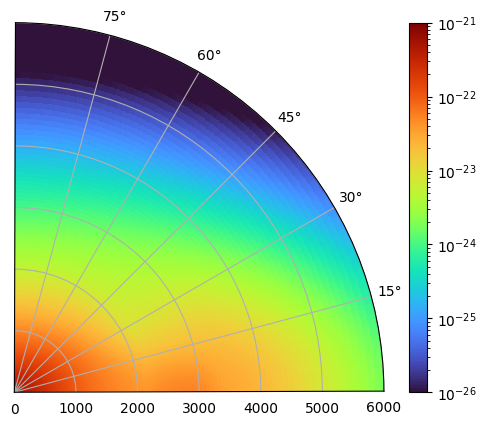

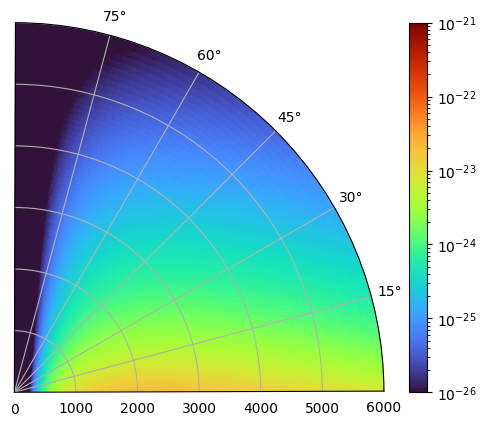

In [20]:
############################################################
# Check the data generating results
##############################
from matplotlib.pyplot import figure, pcolormesh
from numpy import pi

pc = units.pc

tst = binary_io( "../outputs/init_cond/cmz_init_H24.bin" );
tst.open(  );
tst.read(  );

nfig = 0
########################################
# Hydro init cond

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );

aa = tst.as_array( 'hydro_rho' );
rr = tst.as_array( 'hydro_x_0'  );
tt = pi / 2 - tst.as_array( 'hydro_x_1'  );
# pi / 2 - theta for plots only! In Python's polar grid
# the polar angule is actually the latitutde

dd = aa.reshape( len( rr ), len( tt ) );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd, norm =
                     LogNorm( vmin = 1e-26, vmax= 1e-21 ) )
cbar = fig.colorbar( pcm )
ax.set_ylim( 0, 6000 )
print(dd[np.isnan(dd)])

########################################
# Hydro init cond met

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );

aa = tst.as_array( 'hydro_vel' );
rr = tst.as_array( 'hydro_x_0'  );
tt = pi / 2 - tst.as_array( 'hydro_x_1'  );
# pi / 2 - theta for plots only! In Python's polar grid
# the polar angule is actually the latitutde

dd = aa.reshape( len( rr ), len( tt ) );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd/1e5 ,  norm = LogNorm
                     ( vmin = 10, vmax=1000 ))
cbar = fig.colorbar( pcm )
ax.set_ylim( 0, 6000 )
print(dd[np.isnan(dd)])
########################################
# Bar field

aa = tst.as_array( 'bar_data' );
rr = tst.as_array( 'bar_x_0'  );
tt = pi / 2 - tst.as_array( 'bar_x_1'  );
pp = tst.as_array( 'bar_x_2'  );
dd = aa.reshape( len( rr ), len( tt ), len( pp ) );

# Plot the r--theta slices
fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd[ :, :, 0 ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd[ :, :, -1 ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

# Plot the equatorial plance profile
fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( pp.min(  ), pp.max(  ) )
pcm = ax.pcolormesh( pp, rr / pc, dd[ :, -1, : ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

print(dd[np.isnan(dd)])
########################################
# BG DM field

aa = tst.as_array( 'disc_data' );
rr = tst.as_array( 'disc_x_0'  );
tt = pi / 2 - tst.as_array( 'disc_x_1'  );
dd = aa.reshape( len( rr ), len( tt ) );

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd, norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )

cbar = fig.colorbar( pcm )
##############################
# Close the binary_io object
print(dd[np.isnan(dd)])
tst.close(  );
#plt.savefig("test.png",dpi=300)
############################################################